### for normal xavier(Glorot) initialization:

- np.random.randn(no. of input, no. of node)*sqrt(1/fan_in)

### for uniform xavier initialization:

- np.random.randn(no. of input, no. of node)*sqrt(6/fan_in + fan_out)



### Xavier initialization is especially use for sigmoid and tanh activation function

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("ushape.csv")

In [3]:
df.head()

,X,Y,class
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0


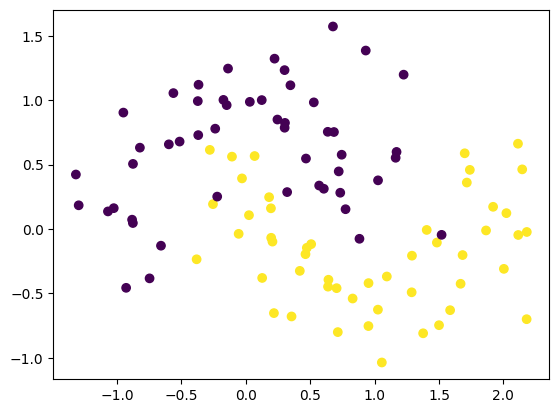

In [4]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [5]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [6]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [7]:
model = Sequential()

model.add(Dense(10,activation='tanh',input_dim=2))
model.add(Dense(10,activation='tanh'))
model.add(Dense(10,activation='tanh'))
model.add(Dense(10,activation='tanh'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

d:\anaconda3\envs\ml_1env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.get_weights()

[array([[-0.56869954, -0.40822273, -0.5246354 ,  0.15891606,  0.6703988 ,
         -0.6554152 , -0.34781888, -0.36488852, -0.21445006,  0.47252327],
        [-0.63653034,  0.48617166, -0.40434456,  0.46756345,  0.46942395,
         -0.14345825, -0.1982677 , -0.00126475,  0.23447269, -0.05128396]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.45723736,  0.1474719 , -0.26997998, -0.3299259 , -0.5387574 ,
         -0.21232885, -0.50886214,  0.17253423,  0.45451152,  0.38833618],
        [-0.3060005 ,  0.3595311 ,  0.47624636, -0.33262438,  0.32315886,
          0.01961392,  0.39946258,  0.4835776 , -0.07296404, -0.06206486],
        [ 0.00156915,  0.49967897,  0.1695888 , -0.50795364,  0.38390404,
          0.08650661, -0.25877362,  0.42415023,  0.46012056, -0.4488828 ],
        [ 0.13578671, -0.4938842 ,  0.20813376,  0.30424958,  0.12424004,
          0.46184528,  0.18092692,  0.13076901, -0.5396561 ,  0.46485376],
        [-0.38288

In [9]:
initial_weights = model.get_weights()

In [10]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [11]:
model.set_weights(initial_weights)

In [12]:
model.get_weights()

[array([[-0.847424  , -0.4173487 , -0.45240736, -0.0822109 , -0.15097675,
          0.44348925,  0.3771818 , -0.8423233 , -0.0704485 ,  0.02882247],
        [ 0.3863488 , -0.70133686, -0.36013618,  1.671089  , -0.8636201 ,
          1.7049485 , -0.3012594 , -0.95896965,  0.02196277,  0.13694976]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.35623044, -0.1348387 ,  0.13194095,  0.6881639 , -0.32869738,
          0.24120006,  0.44223496,  0.28641713, -0.38562033,  0.2532005 ],
        [ 0.31629953, -0.20592482, -0.13669115,  0.9324777 ,  0.48107272,
         -0.10121761, -0.33420002,  0.12394322, -0.14413048,  0.0683283 ],
        [-0.2113155 , -0.21898052,  0.30959487, -0.00308083, -0.37979972,
          0.53750724,  0.50419813,  0.11200967, -0.7436551 ,  0.11884736],
        [-0.28407302,  0.32874033, -0.45984048, -0.00382185,  0.3101611 ,
         -0.44430074,  0.20890382,  0.17130035, -0.46869642, -0.13793617],
        [ 0.41283

In [13]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [14]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.3125 - loss: 0.7294 - val_accuracy: 0.2500 - val_loss: 0.7440
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4000 - loss: 0.7144 - val_accuracy: 0.3500 - val_loss: 0.7235
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4750 - loss: 0.6997 - val_accuracy: 0.4500 - val_loss: 0.7039
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5250 - loss: 0.6849 - val_accuracy: 0.5500 - val_loss: 0.6849
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6250 - loss: 0.6708 - val_accuracy: 0.7000 - val_loss: 0.6670
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7500 - loss: 0.6580 - val_accuracy: 0.8000 - val_loss: 0.6499
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8000 - loss: 0.6448 - val_accuracy: 0.8500 - val_loss: 0.6338
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8125 - loss: 0.6323 - val_accuracy: 0.8500 - val_loss

In [15]:
model.get_weights()

[array([[-0.69360065, -0.44259432, -0.5139698 , -0.03113438, -0.05280749,
          0.57829934,  0.42404148, -0.8242555 ,  0.04108024, -0.11251665],
        [ 0.5638293 , -0.58329743, -0.20750958,  1.6684958 , -0.9245108 ,
          1.7262216 , -0.4692177 , -1.003747  , -0.11656623,  0.2682926 ]],
       dtype=float32),
 array([ 0.11279926,  0.10435213, -0.11055587,  0.07146429,  0.14787321,
         0.19839074, -0.13007075,  0.18463437, -0.00105824,  0.0677029 ],
       dtype=float32),
 array([[ 0.4260607 , -0.11027279,  0.21556233,  0.79189414, -0.23394118,
          0.3261992 ,  0.3982127 ,  0.37912887, -0.31895158,  0.18010233],
        [ 0.28572756, -0.2760056 , -0.20427506,  0.8967774 ,  0.4882547 ,
         -0.18698584, -0.44588655,  0.05599749, -0.07685802,  0.12191557],
        [-0.1652657 , -0.17052677,  0.3708565 ,  0.02021836, -0.2794126 ,
          0.6085532 ,  0.38867456,  0.12520306, -0.6625555 ,  0.0652644 ],
        [-0.22230682,  0.38652593, -0.38722163,  0.0921817 , 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 7s 731us/step


<Axes: >

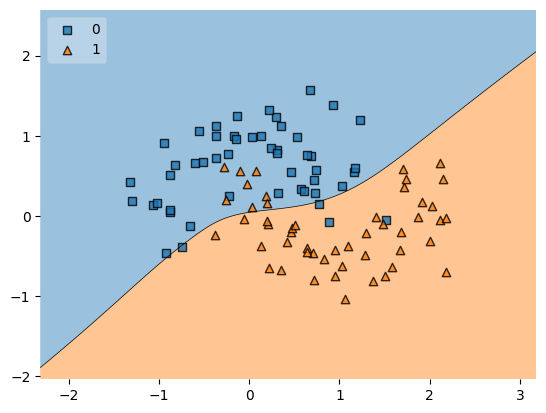

In [16]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'),clf=model,legend=2)